In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import(
    roc_auc_score, average_precision_score, brier_score_loss, log_loss, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as IbmPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

from scipy.stats import chi2_contingency, ttest_ind

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

In [2]:
os.environ['KAGGLE_USERNAME'] = "mohsin416"
os.environ['KAGGLE_KEY'] = "0cbcad64bdb276f31fc1df10a114bd79"

In [3]:
!kaggle competitions download -c playground-series-s6e3

playground-series-s6e3.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip -q playground-series-s6e3.zip

replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
df = pd.read_csv('train.csv')
df.head(1)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No


In [6]:
df.drop('id', axis=1, inplace=True)

print("Shape:", df.shape)

Shape: (594194, 20)


**Basic Checks**

In [7]:
df.info()

print("\nMissing values per column:")
display(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [8]:
df['Churn'] = df['Churn'].map({'Yes' : 1, 'No' : 0})

In [9]:
display(df['Churn'].value_counts())
print("\nTarget rate (Churn=1):", df['Churn'].mean().round(4))

,count
Churn,
0,460377
1,133817



Target rate (Churn=1): 0.2252


In [10]:
x = df.drop('Churn', axis=1)
y = df['Churn'].astype(int)

cat_cols = x.select_dtypes('object').columns.to_list()
num_cols = [c for c in x.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)

Categorical cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [11]:
for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    counts = df[col].value_counts()
    
    print(f"\nChurn rate by {col}:")
    display(pd.DataFrame({
        "Count" : counts,
        "Churn_rate" : churn_rate
    }))


Churn rate by gender:


,Count,Churn_rate
gender,,
Female,298738,0.228036
Male,295456,0.222348



Churn rate by Partner:


,Count,Churn_rate
Partner,,
No,284640,0.324621
Yes,309554,0.133796



Churn rate by Dependents:


...

,Count,Churn_rate
Contract,,
Month-to-month,298918,0.420543
One year,108333,0.057628
Two year,186943,0.009982



Churn rate by PaperlessBilling:


,Count,Churn_rate
PaperlessBilling,,
Yes,365579,0.319387
No,228615,0.074606



Churn rate by PaymentMethod:


,Count,Churn_rate
PaymentMethod,,
Bank transfer (automatic),121360,0.077093
Credit card (automatic),133705,0.069332
Electronic check,215372,0.489052
Mailed check,123757,0.079697


### Plots (distributions + correlations)

**Target distribution**

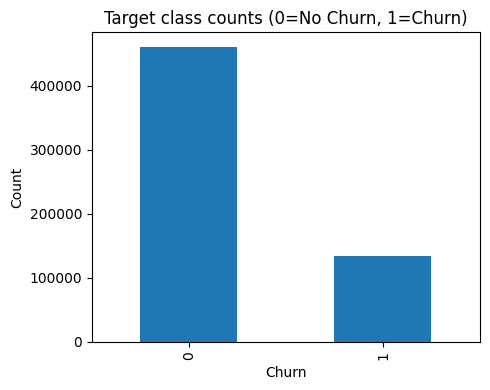

In [12]:
target_col = "Churn"
plt.figure(figsize=(5, 4))
df[target_col].value_counts().sort_index().plot(kind='bar')
plt.title("Target class counts (0=No Churn, 1=Churn)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Histograms for numeric features**

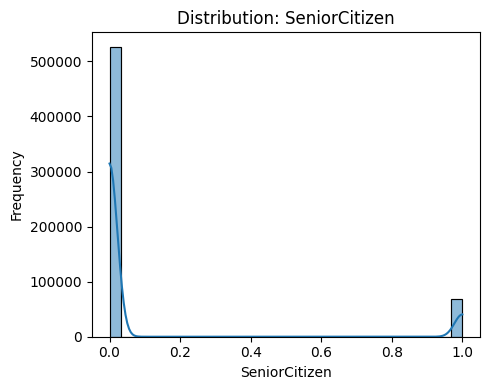

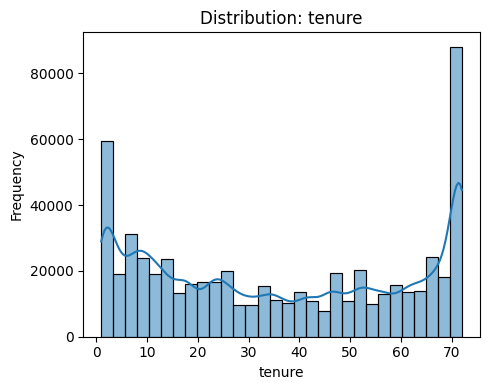

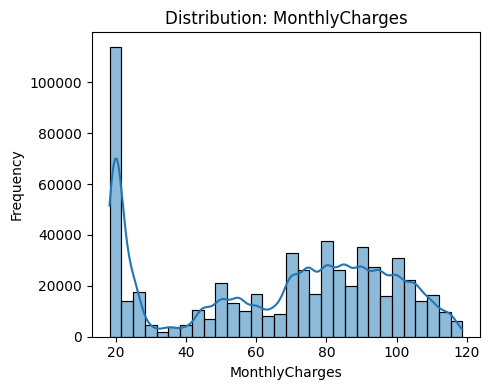

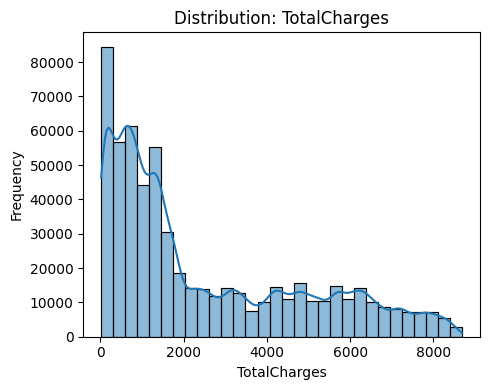

In [13]:
for col in num_cols:
    plt.figure(figsize=(5, 4))
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

**Correlation**

In [ ]:
corr = df[num_cols + [target_col]].corr()[target_col].sort_values(ascending=False)
display(corr.to_frame("corr_with_Churn"))

,corr_with_Churn
Churn,1.000000
MonthlyCharges,0.272997
SeniorCitizen,0.236362
TotalCharges,-0.218365
tenure,-0.418453


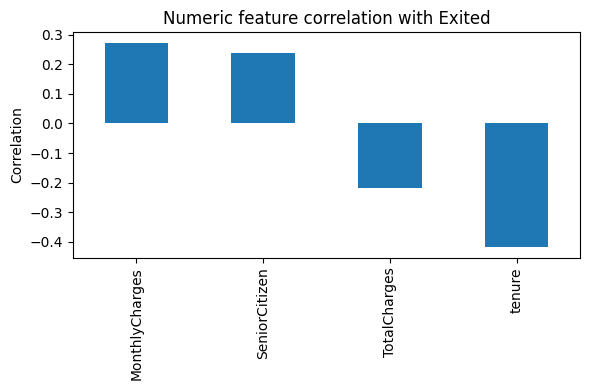

In [ ]:
plt.figure(figsize=(6,4))
corr.drop(target_col).plot(kind="bar")
plt.title("Numeric feature correlation with Exited")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

### statistical tests

**Chi-square tests for categorical columns**

In [ ]:
chi_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(ct)
    chi_results.append((col, chi2, p, dof))

chi_df = pd.DataFrame(chi_results, columns=['feature', 'chi2', 'p_value', 'dof']).sort_values('p_value')
display(chi_df)

,feature,chi2,p_value,dof
1,Partner,30944.982146,0.000000e+00,1
2,Dependents,34329.594977,0.000000e+00,1
5,InternetService,107801.939664,0.000000e+00,2
4,MultipleLines,7888.570524,0.000000e+00,2
6,OnlineSecurity,108175.343877,0.000000e+00,2
7,OnlineBackup,79195.701242,0.000000e+00,2
9,TechSupport,103003.061768,0.000000e+00,2
8,DeviceProtection,72256.065155,0.000000e+00,2
12,Contract,132429.251778,0.000000e+00,2
13,PaperlessBilling,48298.222866,0.000000e+00,1


**Welch t-test for numeric columns**

In [ ]:
ttest_results = []

for col in num_cols:
    a = df.loc[df[target_col]==0, col]
    b = df.loc[df[target_col]==1, col]
    t_stat, p = ttest_ind(a, b, equal_var=False)
    ttest_results.append((col, t_stat, p, a.mean(), b.mean()))
    
tt_df = pd.DataFrame(ttest_results, columns=["feature", "t_stat", "p_value", "mean_no_churn", "mean_churn"]).sort_values("p_value")

display(tt_df)

,feature,t_stat,p_value,mean_no_churn,mean_churn
0,SeniorCitizen,-143.934213,0.0,0.073588,0.253488
1,tenure,415.591634,0.0,42.231313,17.125343
2,MonthlyCharges,-284.223782,0.0,61.293633,81.597525
3,TotalCharges,202.565860,0.0,2771.500515,1540.976020


### Train/test split + preprocessing

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=.20, random_state=42
)

print("Train target rate:", y_train.mean().round(4))
print("Test  target rate:", y_test.mean().round(4))

Train target rate: 0.2252
Test  target rate: 0.2252


In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [ ]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boost" : GradientBoostingClassifier(n_estimators=100,random_state=42),
    "Xgboost" : XGBClassifier(n_estimators=100,random_state=42)
}